# Introduction

in the code demonstration, we will build a basic Sparse Autoencoder from scratch and import a pretrained transformer to visualize it's internal computation with our SAE 

In [ ]:
%pip install scikit-learn torch numpy matplotlib transformers datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 19.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 36.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Importing dataset

In [5]:
ds = load_dataset("wikitext", "wikitext-2-raw-v1", split="train[:2%]")
texts = [t for t in ds["text"] if len(t.strip()) > 20][:1000]

print("number of text samples:", len(texts))
print(texts)

number of text samples: 424
[' = Valkyria Chronicles III = \n', ' Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " Calamaty Raven " . \n', " The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making

# Importing a transformer

using a fast distilled gpt 2 model

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.eval()

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 6680.37it/s]


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [7]:
split_idx = int(0.8 * len(texts))
split_idx

339

In [8]:
split_idx = max(1, min(split_idx, len(texts) - 1))
split_idx

339

In [9]:
train_texts = texts[:split_idx]
test_texts = texts[split_idx:]


In [10]:
train_loader = DataLoader(train_texts, batch_size=8, shuffle=True)
test_loader = DataLoader(test_texts, batch_size=8, shuffle=False)
len(train_loader),len(test_loader)

(43, 11)

# Building SAE

In [11]:
class Encoder(nn.Module):
    # expands
    def __init__(self, input_dim, latent_dim ):
        super().__init__()
        self.ffn1 = nn.Linear(input_dim, latent_dim) # this si basically Wx+b 
        self.relu = nn.ReLU()

    def forward(self, x):
        # get activation input
        # batchidx, dimension 
        u = self.ffn1(x) # batchidx, k where k is the latent dimension, which is often larger than input dimension d, so its an expansion not compression 
        z = self.relu(u) # sparse latent usage 

        return u,z 

# theres also a thought that u can remove sparsity and use linear AE, but the then the linear 
# AE tends toward PCA like subspace behavior, like not the feature level disentanglement we want for interpretability
# so saes push towards parts based selecttive features, not just low rank compression 

In [12]:

class Decoder(nn.Module):
    # compresses back 
    def __init__(self, latent_dim, out_dim):
        super().__init__()
        self.ffn1 = nn.Linear(latent_dim, out_dim)

    def forward(self, x):
        # get latent input
        x = self.ffn1(x) # or basically w_dec z + b_dec where each column of w_dec is a learned feature direction in input space 
        return x 



In [13]:
class SAE(nn.Module):
    def __init__(self, input_dim, latent_dim, output_dim):
        super().__init__()
        # output dim is same as input dim since we want to reconstruct the same activation vector
        self.encoder = Encoder(input_dim, latent_dim)
        self.decoder = Decoder(latent_dim, output_dim)

    def forward(self, x):
        # batchidx, dimension 
        u,z  = self.encoder(x)
        x_hat = self.decoder(z)
        return u,z,x_hat   # batchidx, d
# usually d= 768 then k is 4d or 16d so 3072 or 12288


# a good sae means the model reconstructs x_hat close to x 
# sparse code (z) has only a few non zero entries, 
# so that each feature is more monosemantic and less polisemantic, so that we can interpret each feature as representing a specific concept or meaning in the transformer's computations.


# Eval Loop

In [14]:
# freeze the gpt2 model and pass input text through it to get activations, 
# then train sae to reconstruct those activations on the fly 
# we train on activation vectors: 
# choose layers/component, for each token position, extract x -> R^d, collect many xs across many prompts 
# so training set is D ={x_n}_{n=1..N} where x_n is the activation vector for a particular token in a particular prompt 



# SAE is learning activation geometry that is why we flatten the input insead of learning sequential order 


# each token sate is a sample from layer's activation distribution 

# recon term is for "dont lose information from original activation" and sparsity term is for "learn a sparse code that captures the essence of the activation"
# reconstruct x using the smallest number of features 
# \lambda=0 means only care about recon, \lambda=1 means only care about sparsity, we want to learn a balance between the two 


import torch 
import torch.nn.functional as F 
import torch.nn as nn 
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM 


class SAE_Model:
    def __init__(self, input_dim, latent_dim, output_dim, train_loader, test_loader):
        self.loss_fn = nn.MSELoss() # L2 LOSS
        self.model = SAE(input_dim, latent_dim, output_dim)
        self.gamma_min = 1e-4
        self.gamma_max = 1e-3
        # sparsity vs recon loss, we make it learnable so that model can learn how much 
        # to focus on sparsity vs recon 
        self.gpt2tokenizer = tokenizer
        self.gpt2model = model
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr = 0.001)
        self.model.to(self.device)
        self.gpt2model.to(self.device)
        self.gpt2model.eval()
        for p in self.gpt2model.parameters():
            p.requires_grad = False

    def train(self, epochs=3):
         
        self.model.train()
        # the sparsity loss is just the L1 norm of the latent code z 
        for epoch in range(epochs):
            avgloss=0
            for batch in self.train_loader:
                # get input text and pass through gpt2 to get activations 
                input_text = list(batch)
                inputs = self.gpt2tokenizer(
                    input_text, return_tensors="pt", padding=True, truncation=True, max_length=64
                ).to(self.device)
                with torch.no_grad(): # freeze hidden layer
                    outputs = self.gpt2model(**inputs, output_hidden_states=True)
                    activations = outputs.hidden_states[-1] # get last layer activations 
                    # batchsize x seq_len x hidden_dim 
                    # reshape to X shape i.e Bxseqlen x hidden_dim 
                    B, S, D = activations.shape
                    activations = activations.view(B*S, D) # now we have a big batch of 
                    # activation vectors
                    mask = inputs["attention_mask"].view(B*S).bool()
                    activations = activations[mask]
                u,z,x_hat = self.model(activations)

                recon_loss = self.loss_fn(x_hat, activations)
                sparsity_loss = torch.mean(torch.abs(z)) # L1 norm of latent code 
                gamma = self.gamma_min + (self.gamma_max - self.gamma_min) * (epoch/epochs) # Scaled gamma annealing to gradually increase sparsity pressure over epochs
                loss = recon_loss +  gamma * sparsity_loss 
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                avgloss += loss.item()
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avgloss/len(self.train_loader):.6f}")

    def evaluate(self, sentence, top_k_features=4):
        self.model.eval()
        with torch.no_grad():
            # pass one normal sentence instead of using test_loader loop
            inputs = self.gpt2tokenizer(
                sentence, return_tensors="pt", truncation=True, max_length=64
            ).to(self.device)
            outputs = self.gpt2model(**inputs, output_hidden_states=True)
            activations = outputs.hidden_states[-1] 
            B, S, D = activations.shape
            activations = activations.view(B*S, D) 
            mask = inputs["attention_mask"].view(B*S).bool()
            activations = activations[mask]
            u,z,x_hat = self.model(activations)

        # return response only; visualize outside as needed
        token_ids = inputs["input_ids"].view(-1)[mask]
        tokens = self.gpt2tokenizer.convert_ids_to_tokens(token_ids.tolist()) # convert ids back to token words

        # keep only a small number of tokens so labels are readable
        max_points = min(30, len(tokens), z.shape[0])
        clean_tokens = [tok.replace("Ġ", "") for tok in tokens[:max_points]]
        z_small = z[:max_points].detach().cpu() # num_tokens, num_features

        # choose multiple top features instead of just one
        feature_scores = z_small.mean(dim=0) # shows multiple features, so we can compare how different features respond token-by-token
        k = min(top_k_features, feature_scores.shape[0])
        top_ids = torch.topk(feature_scores, k=k).indices.tolist()

        x_small = activations[:max_points].detach().cpu()
        xhat_small = x_hat[:max_points].detach().cpu()
        token_recon_err = ((xhat_small - x_small) ** 2).mean(dim=1).numpy() #  how well SAE reconstructed each token’s hidden state Higher error means SAE struggled more on that token

        return sentence, clean_tokens, z_small, top_ids, token_recon_err



In [15]:
input_dim = model.config.n_embd
latent_dim = input_dim * 2
output_dim = input_dim

input_dim, latent_dim, output_dim

(768, 1536, 768)

In [16]:

sae_runner = SAE_Model(input_dim, latent_dim, output_dim, train_loader, test_loader)


# Analytics

Each point is a token pooled across multiple sentences.
Position: 2D PCA of its SAE latent activation vector.
Color: cluster assignment in latent space.
Point size: token reconstruction error (higher = larger).

In [17]:
def collect_token_latents(sae_runner, sentences, max_tokens=800):
    all_z = []
    all_tokens = []
    all_recon = []
    all_sentence_ids = []

    for s_idx, sentence in enumerate(sentences):
        _, clean_tokens, z_small, _, token_recon_err = sae_runner.evaluate(sentence)
        for t_idx, tok in enumerate(clean_tokens):
            all_z.append(z_small[t_idx].numpy())
            all_tokens.append(tok)
            all_recon.append(float(token_recon_err[t_idx]))
            all_sentence_ids.append(s_idx)
            if len(all_tokens) >= max_tokens:
                break
        if len(all_tokens) >= max_tokens:
            break

    if not all_z:
        raise ValueError("No tokens collected for clustering.")
    z_matrix = np.vstack(all_z)
    return z_matrix, all_tokens, np.array(all_recon), np.array(all_sentence_ids)


def plot_token_clusters(
    z_matrix,
    tokens,
    recon_err,
    n_clusters=8,
    annotate_per_cluster=3,
    random_state=0,
    ):
    if z_matrix.shape[0] < 2:
        raise ValueError("Need at least 2 tokens to plot clusters.")

    n_clusters = max(1, min(n_clusters, z_matrix.shape[0]))

    scaler = StandardScaler()
    z_scaled = scaler.fit_transform(z_matrix)

    pca = PCA(n_components=2, random_state=random_state)
    z_2d = pca.fit_transform(z_scaled)

    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=random_state)
    labels = kmeans.fit_predict(z_scaled)

    sizes = 30.0
    if recon_err is not None and len(recon_err) == len(tokens):
        err = recon_err.astype(float)
        err_min, err_max = float(err.min()), float(err.max())
        if err_max > err_min:
            sizes = 20 + 80 * (err - err_min) / (err_max - err_min)

    plt.figure(figsize=(10, 6))
    plt.scatter(
        z_2d[:, 0],
        z_2d[:, 1],
        c=labels,
        s=sizes,
        cmap="tab10",
        alpha=0.75,
    )

    # Annotate a few representative tokens per cluster.
    for cluster_id in range(n_clusters):
        cluster_idx = np.where(labels == cluster_id)[0]
        if cluster_idx.size == 0:
            continue
        center = z_2d[cluster_idx].mean(axis=0)
        distances = np.linalg.norm(z_2d[cluster_idx] - center, axis=1)
        pick = cluster_idx[np.argsort(distances)[:annotate_per_cluster]]
        for idx in pick:
            plt.text(z_2d[idx, 0], z_2d[idx, 1], tokens[idx], fontsize=8)

    plt.title("Token clusters in SAE latent space (PCA)")
    plt.xlabel("PCA-1")
    plt.ylabel("PCA-2")
    plt.tight_layout()
    plt.show()

    return labels, z_2d


def summarize_token_clusters(
    z_matrix,
    tokens,
    labels,
    top_k_tokens=6,
    top_k_features=6,
    ):
    n_clusters = int(labels.max()) + 1 if len(labels) else 0
    for cluster_id in range(n_clusters):
        idx = np.where(labels == cluster_id)[0]
        if idx.size == 0:
            continue
        token_counts = Counter([tokens[i] for i in idx])
        top_tokens = [tok for tok, _ in token_counts.most_common(top_k_tokens)]
        mean_activation = z_matrix[idx].mean(axis=0)
        top_features = np.argsort(mean_activation)[-top_k_features:][::-1].tolist()
        print(f"cluster {cluster_id}:")
        print(f"  size: {idx.size}")
        print(f"  top tokens: {top_tokens}")
        print(f"  top feature ids: {top_features}")

In [18]:
sae_runner.train(epochs=3)


Epoch 1/3, Loss: 6.796996
Epoch 2/3, Loss: 0.498130
Epoch 3/3, Loss: 0.270212


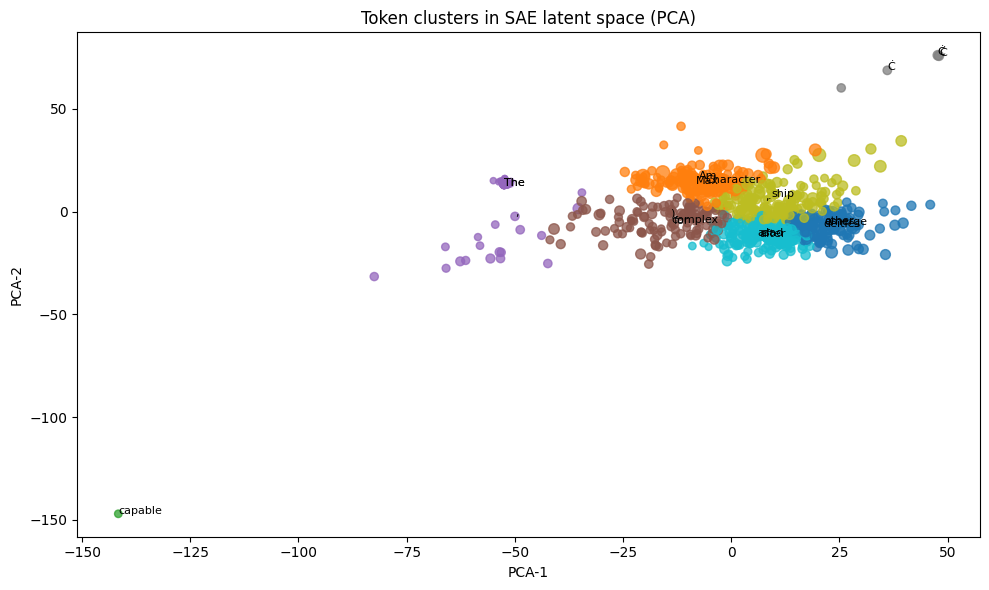

cluster 0:
  size: 133
  top tokens: ['the', 'and', 'deities', 'were', 'to', 'are']
  top feature ids: [1162, 606, 362, 586, 633, 1288]
cluster 1:
  size: 156
  top tokens: ['z', '@', '', 'og', 'Max', 'Er']
  top feature ids: [362, 212, 875, 606, 351, 466]
cluster 2:
  size: 1
  top tokens: ['capable']
  top feature ids: [329, 29, 1522, 867, 166, 608]
cluster 3:
  size: 50
  top tokens: ['=', 'The', 'Cullen', 'For', 'Er', '@']
  top feature ids: [875, 351, 1193, 212, 362, 815]
cluster 4:
  size: 128
  top tokens: ['=', ',', '"', ')', 'War', 'gods']
  top feature ids: [606, 212, 362, 466, 633, 875]
cluster 5:
  size: 4
  top tokens: ['Ċ']
  top feature ids: [137, 875, 732, 926, 362, 348]
cluster 6:
  size: 167
  top tokens: [',', '.', 'Ferdinand', 'her', 'gods', 'Egypt']
  top feature ids: [606, 212, 362, 466, 875, 633]
cluster 7:
  size: 161
  top tokens: ['of', 'the', 'in', 'and', 'to', 'Egyptian']
  top feature ids: [1162, 606, 586, 1288, 633, 362]


In [19]:
cluster_texts = test_texts[:100]
z_matrix, tokens, recon_err, sentence_ids = collect_token_latents(
    sae_runner, cluster_texts, max_tokens=800
 )
labels, z_2d = plot_token_clusters(
    z_matrix, tokens, recon_err, n_clusters=8, annotate_per_cluster=3
 )
summarize_token_clusters(
    z_matrix, tokens, labels, top_k_tokens=6, top_k_features=6
 )